# SDS 210 Final project - Wildfire Mapping

load data, clean it map it in an interactive map


In [1]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\alina\SDS210\SDS_210_repository\sds210-main\sds210-wildfire-project\notebooks
['.ipynb_checkpoints', 'fire_project1.ipynb']


## 1. import all libraries and define API

In [9]:
#setup and imports
import pandas as pd
import requests
import geopandas as gpd
import rasterio
from rasterio.plot import show, show_hist
import matplotlib.pyplot as plt
import folium
from sklearn.cluster import DBSCAN ##for clustering
import numpy as np
import cmcrameri.cm as cmc
from io import StringIO
from datetime import date



In [7]:
##firms API

##map key that i got per mail from nasa
#still do in git ignore later
map_key = 'ae3670ecd91664b2842fe86e1517b552'

#get url, hide map key 
url_api = 'https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?map_key=' + map_key

#check how many transactions i have

reponse = requests.get(url_api)
print(response.status_code)
print(response.text[:200])

200
{ "transaction_limit" : 5000, "current_transactions": 72, "transaction_interval" : "10 minutes" }


## 2. Query data aviability to see what range is aviable for the various datasets
- dataset explanation later
- url will return info abt all supported sensors and their corresponding datasets
- instead of 'all' i could also specify individual sensor like landsat_nrt or smth

In [8]:

##base_url / my_key / what_I_want
da_url = 'https://firms.modaps.eosdis.nasa.gov/api/data_availability/csv/' + map_key + '/all'
df = pd.read_csv(da_url)
display(df)

,data_id,min_date,max_date
0,MODIS_NRT,2026-02-01,2026-05-18
1,MODIS_SP,2000-11-01,2026-01-31
2,VIIRS_NOAA20_NRT,2026-04-01,2026-05-18
3,VIIRS_NOAA20_SP,2018-04-01,2026-03-31
4,VIIRS_NOAA21_NRT,2024-01-17,2026-05-18
5,VIIRS_SNPP_NRT,2026-04-01,2026-05-18
6,VIIRS_SNPP_SP,2012-01-20,2026-03-31
7,LANDSAT_NRT,2022-06-20,2026-05-17
8,GOES_NRT,2022-08-09,2026-05-18
9,BA_MODIS,2000-11-01,2026-02-01


## 3. Define stuff
- bouding box
- sensors to take
- day range to take
- how many detections today

In [14]:
# Borneo BBOX: west, south, east, north
bbox = "108.5,-4.5,119.5,7.5"

# Sensoren: alle drei VIIRS NRT --> near real time
sensors = ["VIIRS_SNPP_NRT", "VIIRS_NOAA20_NRT", "VIIRS_NOAA21_NRT"]

# how many days i wanna look at
day_range = 1



def fetch_firms(sensor, bbox, day_range, map_key, start_date=None):
    """takes FIRMS-Data for a sensor as dataframe."""
    base = "https://firms.modaps.eosdis.nasa.gov/api/area/csv"
    url_api = f"{base}/{map_key}/{sensor}/{bbox}/{day_range}"
    
    if start_date:
        url_api += f"/{start_date}"
    
    r = requests.get(url_api, timeout=60)
    r.raise_for_status() #throws error if theres a problem

    #  safety check --> if response if not a csv, raise error instead of loading garbage data
    if not r.text.startswith("latitude") and "latitude" not in r.text[:200]:
        raise ValueError(f"unexpected response: {r.text[:300]}")

    #response comes back as text, adds column recording which sensor data came from
    df = pd.read_csv(StringIO(r.text))
    df["sensor"] = sensor
    return df

# look at all the sensors and combine
frames = [fetch_firms(s, bbox, day_range, map_key) for s in sensors]
df = pd.concat(frames, ignore_index=True)

print(f"{len(df)} total detections")
print(df.groupby("sensor").size())


11 total detections
sensor
VIIRS_NOAA20_NRT    5
VIIRS_NOAA21_NRT    2
VIIRS_SNPP_NRT      4
dtype: int64


## 4. To datetime and GDF

In [16]:
# Timestamp from acq_date + acq_time (HHMM as int)
#convert to time to sting
#pad to 4 digits, like  830 become 0830
# +" "+ adds aspace btw data and time
#marks it as UTC timezone
df["acq_datetime"] = pd.to_datetime(
    df["acq_date"] + " " + df["acq_time"].astype(str).str.zfill(4),
    format="%Y-%m-%d %H%M",
    utc=True,)

# quality filter : nominal/high confidence, drop the 'l' low, FRP > 0 to remove dead pixels
df = df[df["confidence"].isin(["n", "h"]) & (df["frp"] > 0)].copy()


# GeoDataFrame in WGS84, then UTM 50N (Central-Borneo) reproject
#create point geometry object from coordinate column
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326",
).to_crs("EPSG:32650")


## 5. locate fires near populated areas

- GHS-SMOD (Global Human Settlement Model) 1km resolution raster (ranging from urban centres to very low density rural areas)
- Borneo is btw 2 tiles so i need both
- merge the 2 tiles
- each fire detection sampled against raster to extract settlement
- --> distinguish fires burning in or  near populated areas from those in remote or uninhabited regions

In [24]:
import rasterio
from rasterio.merge import merge
from rasterio.io import MemoryFile
from rasterio.plot import show
import matplotlib.pyplot as plt

#load the 2 raster tiles
tile1 = "../data/GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0_R9_C30.tif"
tile2 = "../data/GHS_SMOD_E2025_GLOBE_R2023A_54009_1000_V2_0_R10_C30.tif"


with rasterio.open(tile1) as src1, rasterio.open(tile2) as src2:
    mosaic, transform = merge([src1, src2]) #transform stores geo metadata
   # dictionary of technical metadata
    #update after merging, height and width bc now its bigger (2 raster)
    #new geographic position of merged raster
    profile = src1.profile.copy()
    profile.update({
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": transform,
    })
    crs = src1.crs

# put Mosaik in a DatasetReader-Object, so .sample() works
with MemoryFile() as memfile:
    with memfile.open(**profile) as mosaic_src:
        mosaic_src.write(mosaic)
        
#for each fire detection point, 
#it looks up what settlement class the underlying raster pixel has.
   
    with memfile.open() as mosaic_src:
        gdf_moll = gdf.to_crs(mosaic_src.crs) #reproject fire to match raster
        coords = [(p.x, p.y) for p in gdf_moll.geometry]
        smod_values = [v[0] for v in mosaic_src.sample(coords)] #extract raster values at each point
        
        # Raster for later for later plot cut here
        #reads the raster into a numpy array (a grid of numbers) so matplotlib can plot it later
        mosaic_array = mosaic_src.read(1) 
        #saves the geographic coordinates of the raster edges
        mosaic_extent = rasterio.plot.plotting_extent(mosaic_src) 

# raster values to readable names, so fire detection knows in what area it is
gdf["smod_class"] = smod_values

smod_labels = {30: "urban_centre", 23: "dense_uc", 22: "semi_dense_uc",
               21: "suburban", 13: "rural_cluster", 12: "low_density_rural",
               11: "very_low_rural", 10: "water"}
gdf["smod_label"] = gdf["smod_class"].map(smod_labels)

print(gdf.groupby("smod_label").size().sort_values(ascending=False))

smod_label
very_low_rural       5
water                3
low_density_rural    1
dense_uc             1
dtype: int64


## 6. Colors for SMOD and visualize

- understand whether fires are occurring near populated areas
- VIIRS fire 
detections are overlaid on the SMOD 2025
-color settlement classes
-project fire detection

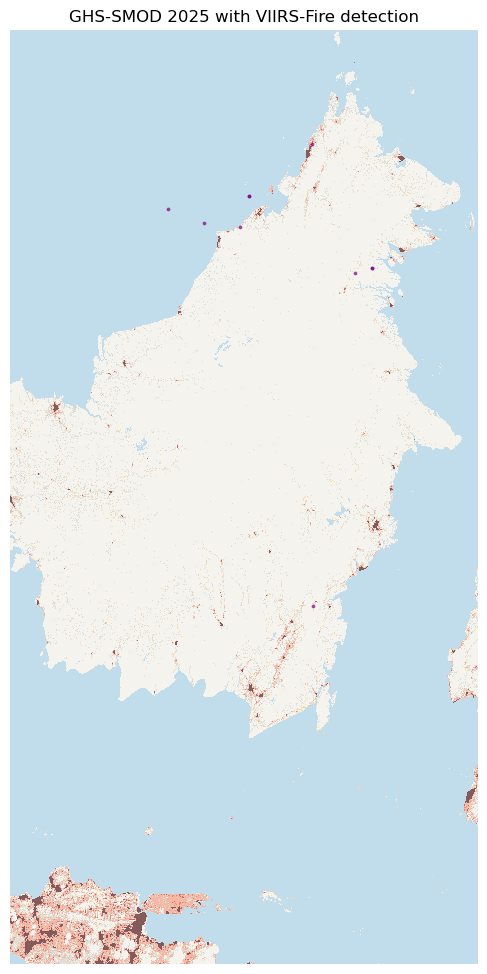

In [29]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

#colors for SMOD-classes (categorical data, no continuous colormap)

smod_colors = {
    10: "#A6CEE3",   # water
    11: "#F1EFE8",   # very low rural
    12: "#D3D1C7",   # low rural
    13: "#FAC775",   # rural cluster
    21: "#F0997B",   # suburban
    22: "#D85A30",   # semi-dense uc
    23: "#A32D2D",   # dense uc
    30: "#501313",   # urban centre
}

# adds an upper boundary so class 30 has a range (30-31)
bounds = sorted(smod_colors.keys()) + [31]
#creates a colormap from  exact list of colors in order
cmap = ListedColormap([smod_colors[k] for k in sorted(smod_colors.keys())])
#which pixel matches whixh color
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(12, 10))

# 1. Raster as background
ax.imshow(mosaic_array, extent=mosaic_extent, cmap=cmap, norm=norm,
          interpolation="nearest", alpha=0.7)

# 2. Points in same CRS overlayed
gdf_moll = gdf.to_crs(crs)
gdf_moll.plot(ax=ax, color="purple", markersize=3, alpha=0.6, zorder=2)

#Zooms the map to exactly the raster bounds
ax.set_xlim(mosaic_extent[0], mosaic_extent[1])
ax.set_ylim(mosaic_extent[2], mosaic_extent[3])
ax.set_title("GHS-SMOD 2025 with VIIRS-Fire detection")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 7. where are fires burning near people?

blablabla


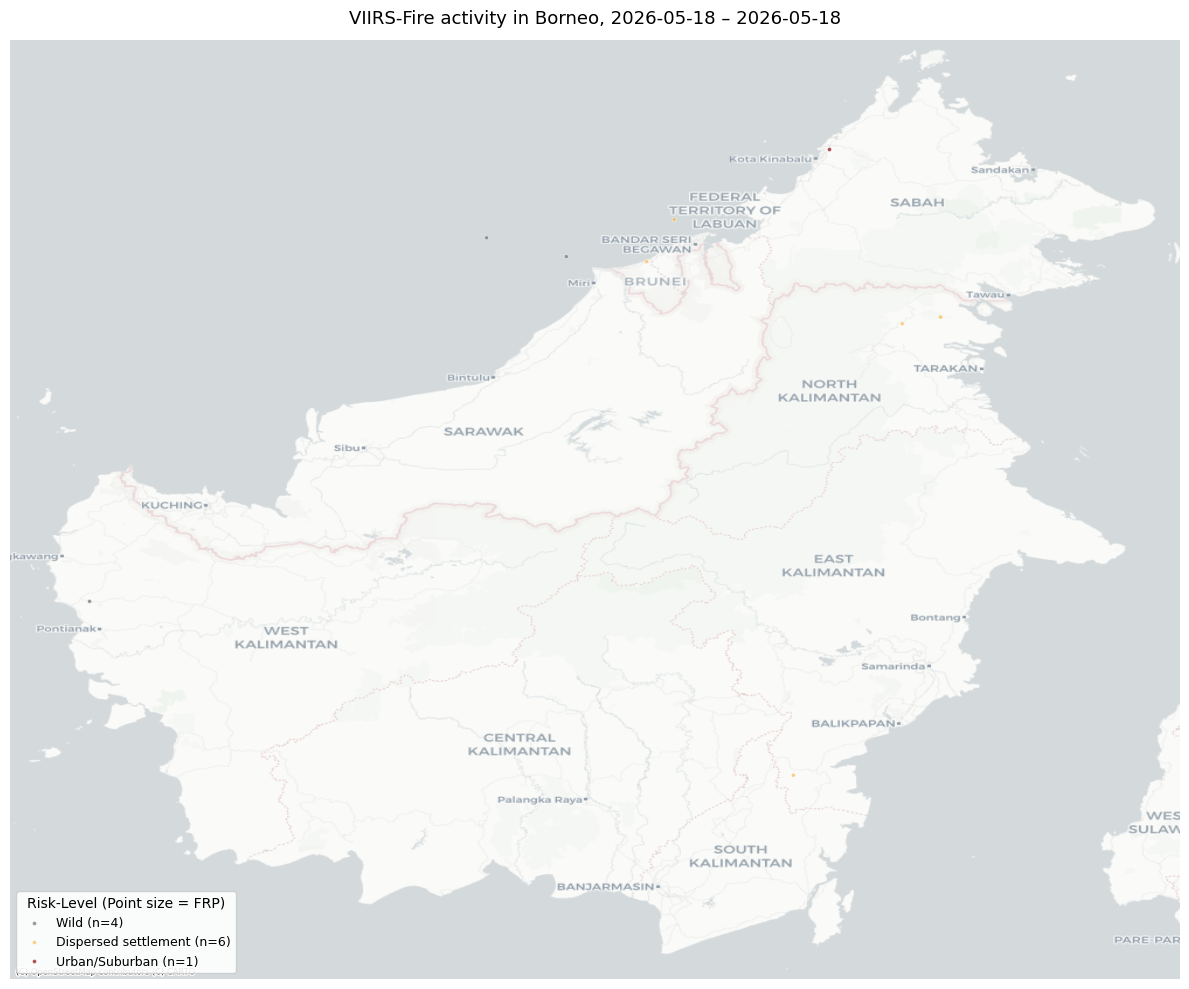

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import contextily as cx
import numpy as np

# gdf has EPSG:32650 already and smod_class as well from step before

# Severity-Mapping: SMOD-class → 4 risk-Level
def smod_to_risk(c):
    if c >= 21: return 3   # urban/suburban: direct impact
    if c == 13: return 2   # rural cluster: village
    if c in (11, 12): return 1   # rural: not much population
    return 0   # water/no data

gdf["risk"] = gdf["smod_class"].apply(smod_to_risk)

fig, ax = plt.subplots(figsize=(12, 10))

# Borneo BBOX in WebMercator for Basemap
borneo_4326 = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([108.5, 119.5], [-4.5, 7.5]),
    crs="EPSG:4326",
).to_crs("EPSG:3857")
xlim = (borneo_4326.geometry.x.min(), borneo_4326.geometry.x.max())
ylim = (borneo_4326.geometry.y.min(), borneo_4326.geometry.y.max())

# points in WebMercator and sorted by risk (high ones are above)
gdf_web = gdf.to_crs("EPSG:3857").sort_values("risk")

risk_colors = {0: "#888780", 1: "#FAC775", 2: "#D85A30", 3: "#A32D2D"}
risk_labels = {0: "Wild", 1: "Dispersed settlement", 2: "Village/cluster", 3: "Urban/Suburban"}

#loop throug each risk level
for level in sorted(gdf_web["risk"].unique()):
    sub = gdf_web[gdf_web["risk"] == level]
    ax.scatter(
        sub.geometry.x, sub.geometry.y,
        #scale size to frp intensity, min 8 max 200
        s=np.clip(sub["frp"] * 0.8, 8, 200),
        c=risk_colors[level],
        edgecolor="white", linewidth=0.3,
        alpha=0.85,
        label=f"{risk_labels[level]} (n={len(sub)})",
        zorder=2 + level,
    )

ax.set_xlim(xlim); ax.set_ylim(ylim)

# Basemap: CartoDB Positron --> neutral, Esri Imagery for Satellite context
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=7, attribution_size=6)

ax.set_axis_off()
ax.legend(
    loc="lower left", frameon=True, framealpha=0.9,
    title="Risk-Level (Point size = FRP)",
    title_fontsize=10, fontsize=9,
)
ax.set_title(
    f"VIIRS-Fire activity in Borneo, {gdf['acq_datetime'].dt.date.min()} – "
    f"{gdf['acq_datetime'].dt.date.max()}",
    fontsize=13, pad=12,
)

plt.tight_layout()
plt.savefig("borneo_fires_wui.png", dpi=200, bbox_inches="tight")
plt.show()

In [31]:
import folium
from folium.plugins import MarkerCluster, HeatMap

# Wieder in WGS84 für Folium
gdf_wgs = gdf.to_crs("EPSG:4326")

# Karte zentrieren auf Borneo
m = folium.Map(
    location=[0.5, 114],
    zoom_start=6,
    tiles="CartoDB positron",
)

# Layer 1: Heatmap aller Detektionen
heat_data = [[p.y, p.x, row["frp"]] for _, row in gdf_wgs.iterrows() for p in [row.geometry]]
HeatMap(heat_data, radius=8, blur=12, name="Wärmekarte FRP").add_to(m)

# Layer 2: Hochrisiko-Feuer als anklickbare Marker
# Create risk column based on settlement type
gdf_wgs["risk"] = gdf_wgs["smod_label"].map({
    "urban_centre": 3,
    "dense_uc": 3,
    "semi_dense_uc": 2,
    "suburban": 2,
    "rural_cluster": 1,
    "low_density_rural": 1,
    "very_low_rural": 1,
    "water": 0
}).fillna(0).astype(int)

high_risk = gdf_wgs[gdf_wgs["risk"] >= 2]
cluster = MarkerCluster(name="Feuer in Menschennähe").add_to(m)

for _, row in high_risk.iterrows():
    color = "darkred" if row["risk"] == 3 else "orange"
    popup_html = f"""
        <b>{row['smod_label']}</b><br>
        Zeit: {row['acq_datetime']:%Y-%m-%d %H:%M UTC}<br>
        Sensor: {row['sensor']}<br>
        FRP: {row['frp']:.1f} MW<br>
        Confidence: {row['confidence']}<br>
        Tag/Nacht: {row['daynight']}
    """
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=max(4, min(row["frp"] / 5, 15)),
        color=color, fill=True, fillOpacity=0.75,
        popup=folium.Popup(popup_html, max_width=250),
    ).add_to(cluster)

folium.LayerControl(collapsed=False).add_to(m)
m.save("borneo_fires_interactive.html")
m